# CNN+LSTM Model - Dataset f04
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_f04.csv

**Architecture:** CNN layers + Bidirectional LSTM + Dense layers

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, Conv1D, MaxPooling1D, LSTM, 
                                   Dropout, BatchNormalization, Flatten, 
                                   GlobalMaxPooling1D, Bidirectional)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset f04
dataset_path = '../dataset step 2/data_features_f04.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (16120, 2)

Columns: ['0', 'label']

Label distribution:
label
sad        3260
angry      3260
fear       3260
disgust    3260
neutral    3080
Name: count, dtype: int64

First few rows:


,0,label
0,0.388470,neutral
1,0.361460,neutral
2,0.385442,neutral
3,0.248624,neutral
4,0.212830,neutral


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (16120, 2)

Class distribution after filtering:
   sad: 3260 samples (20.2%)
   angry: 3260 samples (20.2%)
   fear: 3260 samples (20.2%)
   disgust: 3260 samples (20.2%)
   neutral: 3080 samples (19.1%)

Features shape: (16120, 1)
Number of features: 1
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN+LSTM input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 12896
Test samples: 3224
Reshaped train data: (12896, 1, 1)
Reshaped test data: (3224, 1, 1)
Categorical labels shape: (12896, 5)


In [8]:
# Create CNN+LSTM model
def create_cnn_lstm_model(input_shape, num_classes=5):
    """
    Create CNN+LSTM model for speech emotion recognition
    
    Architecture:
    1. Convolutional layers for local feature extraction
    2. LSTM layers for temporal modeling
    3. Dense layers for classification
    """
    
    inputs = Input(shape=input_shape, name='input')
    
    # CNN Block 1 - Modified for small feature sets
    x = Conv1D(64, kernel_size=1, activation='relu', padding='same', name='conv1d_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    # Skip MaxPooling for very small sequences
    if input_shape[0] > 2:  # Only apply MaxPooling if sequence length > 2
        x = MaxPooling1D(pool_size=2, name='maxpool_1')(x)
    x = Dropout(0.25, name='dropout_1')(x)
    
    # CNN Block 2 - Simplified for small datasets
    x = Conv1D(128, kernel_size=1, activation='relu', padding='same', name='conv1d_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    # Skip second MaxPooling for very small sequences
    if x.shape[1] > 2:  # Only apply if resulting sequence length > 2
        x = MaxPooling1D(pool_size=2, name='maxpool_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)
    
    # CNN Block 3 - Remove for small datasets
    # Skip third CNN block for very small feature sets
    # x = Conv1D(256, kernel_size=3, activation='relu', padding='same', name='conv1d_3')(x)
    # x = BatchNormalization(name='bn_3')(x)
    # x = Dropout(0.25, name='dropout_3')(x)
    
    # LSTM Blocks - Simplified for small sequences
    x = LSTM(64, return_sequences=False, dropout=0.3, recurrent_dropout=0.3, name='lstm_1')(x)
    
    # Dense layers - Simplified for small datasets
    x = Dense(64, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='bn_final')(x)
    x = Dropout(0.5, name='dropout_final')(x)
    
    x = Dense(32, activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='dropout_dense')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs, outputs, name='CNN_LSTM_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_cnn_lstm_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN+LSTM model created and compiled!")
model.summary()

CNN+LSTM model created and compiled!


Model: "CNN_LSTM_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1, 64)          │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 1, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_final (BatchNormalization)   │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,285 (255.02 KB)

 Trainable params: 64,773 (253.02 KB)

 Non-trainable params: 512 (2.00 KB)

In [9]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

#model_checkpoint = ModelCheckpoint(
#    'best_cnn_lstm_f01.h5',
#    monitor='val_accuracy',
#    save_best_only=True,
#    verbose=1
#)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2181 - loss: 2.0154 - val_accuracy: 0.2506 - val_loss: 1.5802 - learning_rate: 0.0010
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2181 - loss: 2.0154 - val_accuracy: 0.2506 - val_loss: 1.5802 - learning_rate: 0.0010
Epoch 2/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2293 - loss: 1.6460 - val_accuracy: 0.2792 - val_loss: 1.5618 - learning_rate: 0.0010
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2293 - loss: 1.6460 - val_accuracy: 0.2792 - val_loss: 1.5618 - learning_rate: 0.0010
Epoch 3/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2445 - loss: 1.6016 - val_accuracy: 0.2894 - val_loss: 1.5546 - learning_rate: 0.0010
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2445 - loss: 1.6016 - val_accuracy: 0.2894 - val_loss: 1.5546 - learning_rate: 0.0010
Epoch 4/100
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accura

In [10]:
# Evaluation and Results
print("CNN+LSTM MODEL EVALUATION - Dataset f04")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CNN+LSTM MODEL EVALUATION - Dataset f04
Test Accuracy: 0.2894
Test Loss: 1.5546

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.3079    0.4018    0.3486       652
     disgust     0.2706    0.2975    0.2834       652
        fear     0.0000    0.0000    0.0000       652
     neutral     0.3060    0.2906    0.2981       616
         sad     0.2782    0.4571    0.3459       652

    accuracy                         0.2894      3224
   macro avg     0.2325    0.2894    0.2552      3224
weighted avg     0.2317    0.2894    0.2547      3224


Cohen's Kappa Score: 0.1115

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.2667
Final Validation Accuracy: 0.2835
Final Training Loss: 1.5644
Final Validation Loss: 1.5527
Epochs Trained: 23
Test Accuracy: 0.2894
Test Loss: 1.5546

CLASSIFICATION REPORT:
--------------------------------------------------


CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   262       143       0         90        157       
disgust 184       194       0         94        180       
fear    223       163       0         88        178       
neutral 76        103       0         179       258       
sad     106       114       0         134       298       


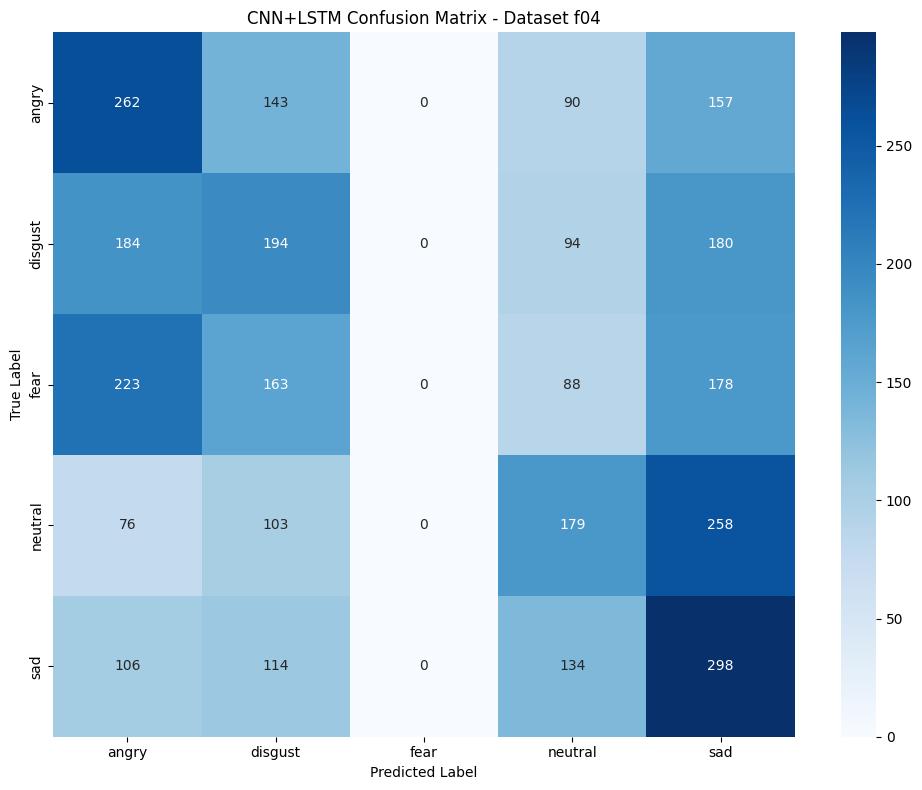

In [11]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('CNN+LSTM Confusion Matrix - Dataset f04')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

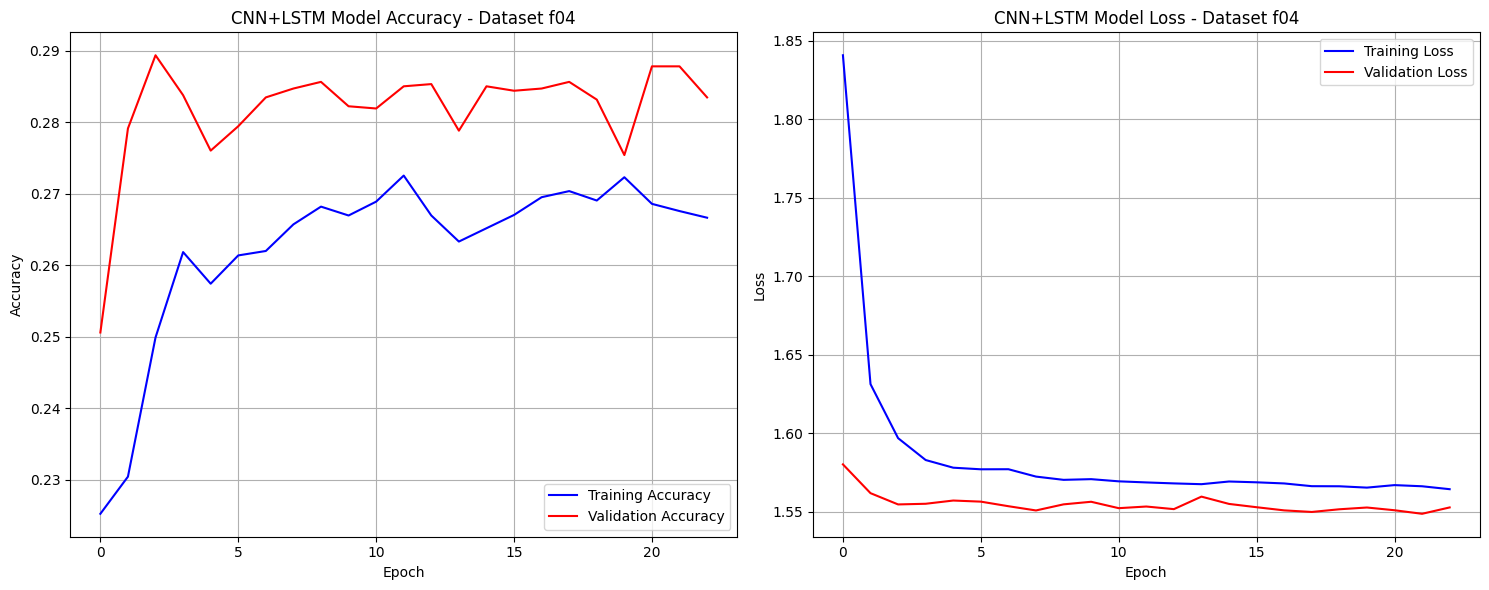

Training history plots generated!


In [12]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('CNN+LSTM Model Accuracy - Dataset f04')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('CNN+LSTM Model Loss - Dataset f04')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [13]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - CNN+LSTM f04")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_f04.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - CNN+LSTM f04
Test Accuracy: 0.2894
Cohen's Kappa: 0.1115
Epochs Trained: 23
Dataset: data_features_f04.csv
Classes: angry, disgust, fear, neutral, sad
